# Laboratorio práctico: ¿qué extractor ve realmente el RAG?

Este cuaderno no elige una herramienta por una tabla de marketing. Hace visible **qué texto, orden, tablas y coordenadas** entrega cada extractor usando los manuales reales. La pregunta que guía todo el laboratorio es: *¿el resultado conserva evidencia que un RAG pueda recuperar y citar?*

Usaremos PyMuPDF, pypdf y pdfplumber como baseline reproducible. Después veremos dos capacidades que los diferencian en la práctica: **coordenadas/orden visual**, **tablas** y **OCR**. Docling y Unstructured quedan como extensiones opcionales, aisladas para que una dependencia pesada no opaque la comparación principal.

## Lo que vamos a comprobar

1. **Cobertura:** ¿cada página devuelve texto?
2. **Orden de lectura:** ¿el fragmento se puede leer y recuperar como evidencia?
3. **Layout:** ¿podemos saber dónde apareció un texto en la página?
4. **Tablas:** ¿hay una estructura de filas/columnas o sólo texto plano?
5. **Escaneos:** ¿el problema es el extractor o hace falta OCR?

In [1]:
from pathlib import Path
import sys
import textwrap

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
sys.path.insert(0, str(ROOT / 'src'))

import fitz
import pandas as pd
from IPython.display import Image, Markdown, display
from laundry_rag.pdf_benchmark import (
    LOCAL_EXTRACTORS, benchmark_corpus, extract_with_pdfplumber,
    extract_with_pymupdf, extract_with_pypdf,
)
from laundry_rag.ingestion import ocr_page

PDFS = sorted((ROOT / 'data' / 'raw').glob('*.pdf'))
pd.DataFrame({'PDF': [pdf.name for pdf in PDFS], 'MB': [round(pdf.stat().st_size / 1_000_000, 1) for pdf in PDFS]})

,PDF,MB
0,ge_233d1597p006_manual_uso_cuidado.pdf,2.2
1,whirlpool_64658698_manual_usuario.pdf,3.3
2,whirlpool_8mwtw1989_manual_uso_cuidado.pdf,20.7
3,whirlpool_krowm000008247.pdf,6.9


## 1. Mismo corpus, tres extractores

Primero medimos velocidad y cobertura. Estas métricas son un filtro inicial: muchos caracteres no garantizan que el orden o la estructura sean útiles.

In [2]:
resultados = pd.DataFrame(benchmark_corpus(PDFS))
display(resultados.sort_values(['archivo', 'extractor']))

resumen = (resultados.groupby('extractor', as_index=False)
           .agg(paginas=('páginas', 'sum'), paginas_con_texto=('páginas_con_texto', 'sum'),
                caracteres=('caracteres', 'sum'), ms=('ms', 'sum'), tablas=('tablas_detectadas', 'sum'))
           .sort_values('ms'))
resumen

,archivo,extractor,páginas,páginas_con_texto,caracteres,tablas_detectadas,ms,error
0,ge_233d1597p006_manual_uso_cuidado.pdf,PyMuPDF,46,45,81085,0,149.3,None
2,ge_233d1597p006_manual_uso_cuidado.pdf,pdfplumber,46,45,149214,16,3612.1,None
1,ge_233d1597p006_manual_uso_cuidado.pdf,pypdf,46,45,82829,0,1493.0,None
3,whirlpool_64658698_manual_usuario.pdf,PyMuPDF,11,11,33672,0,65.8,None
5,whirlpool_64658698_manual_usuario.pdf,pdfplumber,11,11,29185,5,562.3,None
4,whirlpool_64658698_manual_usuario.pdf,pypdf,11,11,33718,0,97.0,None
6,whirlpool_8mwtw1989_manual_uso_cuidado.pdf,PyMuPDF,20,20,61070,0,852.9,None
8,whirlpool_8mwtw1989_manual_uso_cuidado.pdf,pdfplumber,20,20,60397,24,8624.4,None
7,whirlpool_8mwtw1989_manual_uso_cuidado.pdf,pypdf,20,20,61043,0,5311.9,None
9,whirlpool_krowm000008247.pdf,PyMuPDF,16,0,0,0,16.1,None


,extractor,paginas,paginas_con_texto,caracteres,ms,tablas
0,PyMuPDF,93,76,175827,1084.1,0
2,pypdf,93,76,177590,6905.3,0
1,pdfplumber,93,76,238796,12805.0,45


**Interpretación:** si una fila tiene `páginas_con_texto = 0` para el manual escaneado, no concluyas que el parser sea malo: el PDF sólo contiene imágenes. Ésa es la señal para introducir OCR.

## 2. La misma página visual y el texto que entrega cada herramienta

Cambia `PDF_DEMO` y `PAGINA_DEMO`. La imagen es la fuente de verdad: compara su disposición con los tres extractos de abajo. Esta es la prueba que una tabla de caracteres no puede hacer.

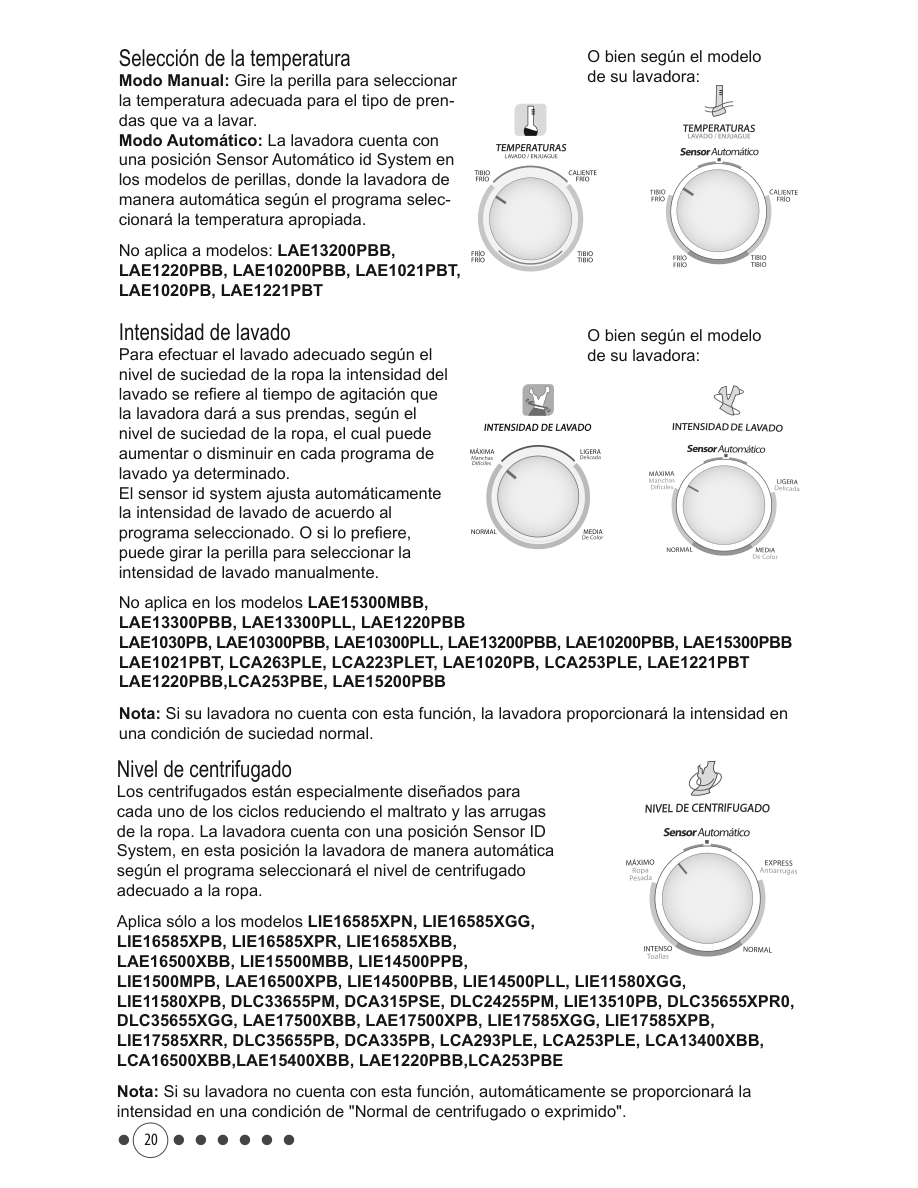

ge_233d1597p006_manual_uso_cuidado.pdf · página 20


In [3]:
PDF_DEMO = next(pdf for pdf in PDFS if '233d1597' in pdf.name)
PAGINA_DEMO = 20  # prueba otra página donde haya listas, controles o tablas

with fitz.open(PDF_DEMO) as document:
    page = document[PAGINA_DEMO - 1]
    preview = page.get_pixmap(matrix=fitz.Matrix(1.5, 1.5), alpha=False).tobytes('png')
display(Image(preview, width=620))
print(f'{PDF_DEMO.name} · página {PAGINA_DEMO}')

In [4]:
salidas = {nombre: extractor(PDF_DEMO)[PAGINA_DEMO - 1] for nombre, extractor in LOCAL_EXTRACTORS.items()}
comparacion = pd.DataFrame([
    {
        'extractor': nombre, 'caracteres': len(salida.text), 'tablas candidatas': salida.tables,
        'primeras 450 letras': salida.text[:450].replace('\n', ' ↵ ') or '[sin texto]'
    }
    for nombre, salida in salidas.items()
])
display(comparacion)

for nombre, salida in salidas.items():
    display(Markdown(f'### {nombre}'))
    print(salida.text[:1_500] or '[sin texto]')
    print('─' * 100)

,extractor,caracteres,tablas candidatas,primeras 450 letras
0,PyMuPDF,2276,0,20 ↵ Intensidad de lavado ↵ Para efectuar el l...
1,pypdf,2303,0,20 ↵ Intensidad de lavado ↵ Para efectuar el...
2,pdfplumber,2245,0,Selección de la temperatura O bien según el mo...


### PyMuPDF

20
Intensidad de lavado
Para efectuar el lavado adecuado según el 
nivel de suciedad de la ropa la intensidad del 
la lavadora dará a sus prendas, según el 
nivel de suciedad de la ropa, el cual puede 
aumentar o disminuir en cada programa de 
lavado ya determinado.
El sensor id system ajusta automáticamente 
la intensidad de lavado de acuerdo al 
puede girar la perilla para seleccionar la 
intensidad de lavado manualmente.
Selección de la temperatura
Modo Manual: Gire la perilla para seleccionar 
la temperatura adecuada para el tipo de pren-
das que va a lavar.
Modo Automático: La lavadora cuenta con 
una posición Sensor Automático id System en 
los modelos de perillas, donde la lavadora de 
manera automática según el programa selec-
cionará la temperatura apropiada.
No aplica a modelos: LAE13200PBB, 
LAE1220PBB, LAE10200PBB, LAE1021PBT, 
LAE1020PB, LAE1221PBT
O bien según el modelo 
de su lavadora:
No aplica en los modelos LAE15300MBB,
LAE13300PBB, LAE13300PLL, LAE1220PBB
LAE1030PB, 

### pypdf

20 
Intensidad de lavado 
Para efectuar el lavado adecuado según el 
nivel de suciedad de la ropa la intensidad del 
la lavadora dará a sus prendas, según el 
nivel de suciedad de la ropa, el cual puede 
aumentar o disminuir en cada programa de 
lavado ya determinado. 
El sensor id system ajusta automáticamente 
la intensidad de lavado de acuerdo al 
puede girar la perilla para seleccionar la 
intensidad de lavado manualmente. 
Selección de la temperatura 
Modo Manual:  Gire la perilla para seleccionar 
la temperatura adecuada para el tipo de pren- 
das que va a lavar. 
Modo Automático:  La lavadora cuenta con 
una posición Sensor Automático id System en 
los modelos de perillas, donde la lavadora de 
manera automática según el programa selec- 
cionará la temperatura apropiada. 
No aplica a modelos: LAE13200PBB, 
LAE1220PBB, LAE10200PBB, LAE1021PBT, 
LAE1020PB, LAE1221PBT 
O bien según el modelo 
de su lavadora: 
No aplica en los modelos  LAE15300MBB, 
LAE13300PBB, LAE13300PLL, LAE1220

### pdfplumber

Selección de la temperatura O bien según el modelo
Modo Manual: Gire la perilla para seleccionar de su lavadora:
la temperatura adecuada para el tipo de pren-
das que va a lavar.
Modo Automático: La lavadora cuenta con
una posición Sensor Automático id System en
los modelos de perillas, donde la lavadora de
manera automática según el programa selec-
cionará la temperatura apropiada.
No aplica a modelos: LAE13200PBB,
LAE1220PBB, LAE10200PBB, LAE1021PBT,
LAE1020PB, LAE1221PBT
Intensidad de lavado
O bien según el modelo
Para efectuar el lavado adecuado según el de su lavadora:
nivel de suciedad de la ropa la intensidad del
la lavadora dará a sus prendas, según el
nivel de suciedad de la ropa, el cual puede
aumentar o disminuir en cada programa de
lavado ya determinado.
El sensor id system ajusta automáticamente
la intensidad de lavado de acuerdo al
puede girar la perilla para seleccionar la
intensidad de lavado manualmente.
No aplica en los modelos LAE15300MBB,
LAE13300PBB, LAE13300PLL, L

**Discusión para clase:** busca una frase que aparezca visualmente al lado de un control o encabezado. ¿El extractor la deja cerca de su contexto? Si el texto se mezcla, un chunker posterior puede cortar evidencia equivocada aunque el conteo de caracteres sea alto.

## 3. Una diferencia concreta: PyMuPDF conserva coordenadas

PyMuPDF no sólo devuelve texto. Puede entregar bloques y palabras con `x0, y0, x1, y1`. Esto permite resaltar en el PDF de dónde salió un chunk, justo como en el laboratorio de chunking. pypdf devuelve texto, pero no estas coordenadas; pdfplumber también expone layout, especialmente útil para depurar tablas.

In [5]:
with fitz.open(PDF_DEMO) as document:
    page = document[PAGINA_DEMO - 1]
    blocks = page.get_text('blocks', sort=True)
    words = page.get_text('words', sort=True)

bloques = pd.DataFrame(blocks, columns=['x0', 'y0', 'x1', 'y1', 'texto', 'bloque', 'tipo'])
display(bloques[['x0', 'y0', 'x1', 'y1', 'texto']].head(8))

palabras = pd.DataFrame(words, columns=['x0', 'y0', 'x1', 'y1', 'palabra', 'bloque', 'línea', 'número'])
display(palabras.head(20))
print('Lectura por coordenadas:', ' '.join(palabras['palabra'].head(35)))

,x0,y0,x1,y1,texto
0,391.475861,32.794968,510.688080,56.994972,O bien según el modelo \nde su lavadora:\n
1,79.141373,33.526112,307.719147,152.368515,Selección de la temperatura\nModo Manual: Gire...
2,79.141373,162.334824,310.285553,199.734848,"No aplica a modelos: LAE13200PBB, \nLAE1220PBB..."
3,391.475861,219.042953,510.688080,243.242966,O bien según el modelo \nde su lavadora:\n
4,79.141373,216.061020,301.665894,255.703964,Intensidad de lavado\nPara efectuar el lavado ...
5,79.141373,271.103912,297.376465,348.103912,"la lavadora dará a sus prendas, según el \nniv..."
6,79.141373,363.503845,277.181061,387.703857,puede girar la perilla para seleccionar la \ni...
7,79.142975,396.959808,528.317810,460.760742,"No aplica en los modelos LAE15300MBB,\nLAE1330..."


,x0,y0,x1,y1,palabra,bloque,línea,número
0,79.141373,33.526112,132.987442,47.416016,Selección,4,0,0
1,136.441391,33.526112,150.254456,47.416016,de,4,0,1
2,153.708405,33.526112,163.371811,47.416016,la,4,0,2
3,166.825729,33.526112,233.795624,47.416016,temperatura,4,0,3
4,391.475861,32.794968,400.033844,43.794960,O,6,0,0
5,403.095520,32.794968,423.880249,43.794960,bien,6,0,1
6,426.938385,32.794968,456.897278,43.794960,según,6,0,2
7,459.955414,32.794968,468.511688,43.794960,el,6,0,3
8,471.569672,32.794968,507.631775,43.794960,modelo,6,0,4
9,79.141373,48.968979,108.470734,59.968971,Modo,4,1,0


Lectura por coordenadas: Selección de la temperatura O bien según el modelo Modo Manual: Gire la perilla para seleccionar de su lavadora: la temperatura adecuada para el tipo de pren- das que va a lavar. Modo Automático: La


## 4. Una diferencia concreta: pdfplumber intenta recuperar tablas

Una tabla útil para RAG necesita filas y columnas, no sólo palabras consecutivas. Esta celda busca la primera página del corpus donde pdfplumber detecta una tabla y muestra una vista previa. Si no encuentra ninguna, el resultado también es evidencia: esos manuales pueden contener diagramas/listas, no tablas vectoriales.

In [16]:
import pdfplumber

tabla_encontrada = None
for pdf in PDFS:
    with pdfplumber.open(pdf) as document:
        for numero, page in enumerate(document.pages, start=1):
            tables = page.extract_tables()
            if tables and numero != 12:
                tabla_encontrada = (pdf, numero, tables[0])
                break
    if tabla_encontrada:
        break

if tabla_encontrada:
    pdf, numero, tabla = tabla_encontrada
    print(f'Tabla candidata: {pdf.name} · página {numero}')
    display(pd.DataFrame(tabla).head(10))
else:
    print('pdfplumber no detectó tablas con su configuración por defecto en estos manuales.')
    print('Eso no significa que no haya información tabular: inspecciona diagramas y prueba settings de tabla antes de cambiar de extractor.')

Cannot set non-stroke color: /'R76' is an invalid float value
Cannot set non-stroke color: /'R80' is an invalid float value
Cannot set non-stroke color: /'R98' is an invalid float value
Cannot set non-stroke color: /'R102' is an invalid float value
Cannot set non-stroke color: /'R104' is an invalid float value
Cannot set non-stroke color: /'R115' is an invalid float value
Cannot set non-stroke color: /'R117' is an invalid float value
Cannot set non-stroke color: /'R119' is an invalid float value
Cannot set non-stroke color: /'R121' is an invalid float value
Cannot set non-stroke color: /'R123' is an invalid float value
Cannot set non-stroke color: /'R134' is an invalid float value
Cannot set non-stroke color: /'R141' is an invalid float value
Cannot set non-stroke color: /'R143' is an invalid float value
Cannot set non-stroke color: /'R145' is an invalid float value
Cannot set non-stroke color: /'R147' is an invalid float value
Cannot set non-stroke color: /'R149' is an invalid float v

Tabla candidata: ge_233d1597p006_manual_uso_cuidado.pdf · página 18


,0,1,2,3
0,Lavado pesado\ncon ropa muy\nsucia o prendas\n...,Este ciclo está\ndiseñado para\ndar un lavado ...,Ciclo que realiza\nun buen lavado\ncon cuidado...,Ciclo diseñado\nespecialmente\npara blancos.
1,Sensor Automático\n(modelos id system)\nMínimo...,Sensor Automático\n(modelos id system)\nMínimo...,Sensor Automático\n(modelos id system)\nMínimo...,Sensor Automático\n(modelos id system)\nMínimo...
2,Caliente/Frío,Tibio/Frío,Frío/Frío,Tibio/Frío


## 5. El caso que cambia la decisión: PDF escaneado → OCR

Los tres extractores nativos suelen fallar en el manual escaneado. Aquí no los comparamos contra OCR como si fueran equivalentes: mostramos la transición correcta de *sin capa de texto* a *texto OCR*, que es el flujo que usa el proyecto.

In [7]:
PDF_ESCANEADO = next(pdf for pdf in PDFS if 'krowm' in pdf.name)
PAGINA_OCR = 1
nativo = {nombre: extractor(PDF_ESCANEADO)[PAGINA_OCR - 1].text for nombre, extractor in LOCAL_EXTRACTORS.items()}

with fitz.open(PDF_ESCANEADO) as document:
    texto_ocr = ocr_page(document[PAGINA_OCR - 1])

display(pd.DataFrame([
    {'ruta': nombre, 'caracteres': len(texto), 'muestra': texto[:180].replace('\n', ' ↵ ') or '[sin texto]'}
    for nombre, texto in nativo.items()
] + [{'ruta': 'Tesseract OCR (flujo del proyecto)', 'caracteres': len(texto_ocr), 'muestra': texto_ocr[:180].replace('\n', ' ↵ ')}]))

print('Muestra OCR:\n', texto_ocr[:1_200])

,ruta,caracteres,muestra
0,PyMuPDF,0,[sin texto]
1,pypdf,0,[sin texto]
2,pdfplumber,0,[sin texto]
3,Tesseract OCR (flujo del proyecto),397,LG ↵ LAVADORA ↵ ↵ MODELO : WF-T5501PP/ WE-T61...


Muestra OCR:
 LG
LAVADORA

MODELO : WF-T5501PP/ WE-T6105TP
WF-T5505PP/ WF-T6505TP

Por favor, lea atentamente este manual antes de utilizar el
electrodméstico. Guardelo para posible consulta.

Anote el numero de modelo y el numero de serie del aparato.
Observe la etiqueta pegada sobre la cubierta posterior y
proporcione esta información a su distribuidor cuando
necesite servicio técnico.

P/No.: 3828EA3008V



## 6. Docling y Unstructured: extensiones con una pregunta concreta

Úsalos sólo si el baseline anterior revela una necesidad concreta: Markdown jerárquico, tablas complejas o elementos de layout (`Title`, `Table`, `NarrativeText`). Los bloques siguientes no detienen el notebook si la instalación no está lista.

El error `Numba needs NumPy 2.4 or less` de Unstructured no es un resultado de extracción: es un conflicto de entorno. Este proyecto fija `numpy<2.5`; ejecuta `uv sync` y reinicia el kernel antes de probar `hi_res`.

In [17]:
# Docling: compara una salida estructurada (Markdown), no sólo un conteo de caracteres.
try:
    from docling.document_converter import DocumentConverter
    resultado_docling = DocumentConverter().convert(PDF_DEMO)
    markdown_docling = resultado_docling.document.export_to_markdown()
    print(markdown_docling[:5_000])
except Exception as error:
    print('Docling no quedó listo en este entorno:', type(error).__name__, error)
    print('Instala/sincroniza dependencias sólo si necesitas estructura Markdown o tablas complejas.')

[INFO] 2026-07-17 18:41:33,699 [RapidOCR] base.py:23: Using engine_name: onnxruntime
[INFO] 2026-07-17 18:41:33,711 [RapidOCR] download_file.py:60: File exists and is valid: /Users/andrei/Documents/Projects/Tutorials-Resources/LLM_para_Proyectos_en_Ciencia_de_Datos/rag/.venv/lib/python3.12/site-packages/rapidocr/models/PP-OCRv6_det_small.onnx
[INFO] 2026-07-17 18:41:33,712 [RapidOCR] main.py:63: Using /Users/andrei/Documents/Projects/Tutorials-Resources/LLM_para_Proyectos_en_Ciencia_de_Datos/rag/.venv/lib/python3.12/site-packages/rapidocr/models/PP-OCRv6_det_small.onnx
[INFO] 2026-07-17 18:41:33,746 [RapidOCR] base.py:23: Using engine_name: onnxruntime
[INFO] 2026-07-17 18:41:33,749 [RapidOCR] download_file.py:60: File exists and is valid: /Users/andrei/Documents/Projects/Tutorials-Resources/LLM_para_Proyectos_en_Ciencia_de_Datos/rag/.venv/lib/python3.12/site-packages/rapidocr/models/ch_ppocr_mobile_v2.0_cls_mobile.onnx
[INFO] 2026-07-17 18:41:33,749 [RapidOCR] main.py:63: Using /Users

<!-- image -->

<!-- image -->

## Manual de Uso y Cuidado

## Lavadoras

Lea este manual para poder aprovechar al máximo su lavadora.

<!-- image -->

1

## Indice

| Precauciones                                                                                                             | ..................................................................................3   |
|--------------------------------------------------------------------------------------------------------------------------|---------------------------------------------------------------------------------------|
| Instalación adecuada.                                                                                                    |                                                                                       |
| Cuando use su lavadora                                                                                                   | ................................................................. 5   

In [9]:
# Unstructured: la evidencia distintiva son tipos de elementos, no caracteres.
try:
    import numpy as np
    if np.lib.NumpyVersion(np.__version__) >= '2.5.0':
        raise RuntimeError(f'NumPy {np.__version__}: ejecuta `uv sync` para aplicar numpy<2.5 y reinicia el kernel.')
    from unstructured.partition.pdf import partition_pdf
    elements = partition_pdf(filename=str(PDF_DEMO), strategy='hi_res', infer_table_structure=True, languages=['spa'])
    display(pd.DataFrame([
        {'tipo': type(element).__name__, 'texto': str(element)[:260]} for element in elements[:25]
    ]))
except Exception as error:
    print('Unstructured no se ejecutó:', type(error).__name__, error)
    print('Después de `uv sync`, reinicia el kernel. hi_res además puede descargar modelos de layout/OCR.')

Loading weights: 100%|██████████| 367/367 [00:00<00:00, 26345.86it/s]


,tipo,texto
0,Image,
1,Image,
2,Title,Manual de Uso y Cuidado
3,Text,Lavadoras
4,Image,
5,NarrativeText,Lea este manual para poder aprovechar al máxim...
6,NarrativeText,233D1597P006
7,Image,"y) NOM-4 PA—Ák O CER7, A Á o, o E y S > o ED PRO"
8,Title,Indice
9,NarrativeText,PTecauciOnNesS ...omcconcconnconnccnaccnnaronn...


## Decisión para este RAG

- **PyMuPDF + OCR de respaldo:** baseline del curso. Es rápido, permite páginas, bloques y coordenadas; ya alimenta el laboratorio de chunking.
- **pdfplumber:** añádelo cuando las tablas detectadas aporten evidencia que el texto lineal pierde.
- **pypdf:** útil si tu flujo ya usa pypdf para manipular PDFs, pero no aporta OCR ni una ventaja de layout para este RAG.
- **Docling / Unstructured:** justifícalos con un ejemplo real donde jerarquía, tabla o tipos de elemento cambien la evidencia recuperada.

La decisión final no es «qué herramienta extrae más», sino «qué salida permite recuperar, citar y explicar correctamente la evidencia».